### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)

from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

### Load MIMIC Data

In [2]:
import os

data_path = "../../../Documents/Learning/MS_AI/AI_In_Healthcare/Dataset/mimic-iii-clinical-database-1.4/"
print(os.path.exists(data_path))

True


In [3]:
patients = pd.read_csv(data_path + "PATIENTS.csv.gz")
admissions = pd.read_csv(data_path + "ADMISSIONS.csv.gz")
icustays = pd.read_csv(data_path + "ICUSTAYS.csv.gz")

prescriptions = pd.read_csv(
    data_path + "PRESCRIPTIONS.csv.gz",
    usecols=["HADM_ID", "DRUG", "STARTDATE", "DOSE_VAL_RX"],
    low_memory=False
)

prescriptions["DOSE_VAL_RX"] = pd.to_numeric(
    prescriptions["DOSE_VAL_RX"], errors="coerce"
)

chartevents = pd.read_csv(
    data_path + "CHARTEVENTS.csv.gz",
    usecols=["SUBJECT_ID","HADM_ID","ITEMID","VALUENUM","CHARTTIME"],
    parse_dates=["CHARTTIME"],
    compression="gzip"
)

labevents = pd.read_csv(
    data_path + "LABEVENTS.csv.gz",
    usecols=["SUBJECT_ID","HADM_ID","ITEMID","VALUENUM","CHARTTIME"],
    parse_dates=["CHARTTIME"]
)

### Feature Extractions

##### Clinical Definition (Sepsis-3)

Sepsis =
Suspected infection +
Organ dysfunction (SOFA ↑ ≥ 2)

##### Implementation Strategy (MIMIC-friendly)

We approximate:

Infection → antibiotics (PRESCRIPTIONS)
Organ dysfunction → labs (creatinine, platelets, bilirubin)

In [4]:
# Infection Flag

# Antibiotics list 
antibiotics = [
    "vancomycin", "cefepime", "piperacillin", "meropenem",
    "zosyn", "ceftriaxone", "ceftazidime",
    "azithromycin", "levofloxacin", "ciprofloxacin",
    "ampicillin", "amoxicillin", "clindamycin",
    "linezolid", "doxycycline", "metronidazole"
]

prescriptions["drug_lower"] = prescriptions["DRUG"].str.lower()
abx = prescriptions[prescriptions["drug_lower"].str.contains('|'.join(antibiotics), na=False)]

abx = abx.copy()
abx["STARTDATE"] = pd.to_datetime(abx["STARTDATE"])
infection_time = (
    abx.groupby("HADM_ID")["STARTDATE"]
    .min()
    .reset_index()
    .rename(columns={"STARTDATE": "infection_time"})
)

In [5]:
# Critical Clinical Indicators for Sepsis Prediction

# Vitals
# SpO2 (Oxygen Saturation)
SPO2_IDS = [220277, 646]
# MAP (Mean Arterial Pressure)
MAP_IDS = [220181, 220052]
# GCS (Glasgow Coma Scale Total)
GCS_IDS = [223901, 220739]
FIO2_IDS = [223835, 3420]


# Labs

CREATININE_ID = 50912
PLATELETS_ID = 51265
LACTATE_ID = 50813
WBC_ID = 51300

In [6]:
# Organ Dysfunction (SOFA proxy)

# Example lab thresholds (simplified SOFA proxy)
labs = labevents.copy()

# Creatinine (renal dysfunction)
creatinine = labs[labs["ITEMID"] == CREATININE_ID].groupby("HADM_ID")["VALUENUM"].max().reset_index()
creatinine["renal"] = (creatinine["VALUENUM"] > 2.0).astype(int)

# Platelets (coagulation)
platelets = labs[labs["ITEMID"] == PLATELETS_ID].groupby("HADM_ID")["VALUENUM"].min().reset_index()
platelets["coag"] = (platelets["VALUENUM"] < 100).astype(int)

# Lactate
lactate = labs[labs["ITEMID"] == LACTATE_ID] \
    .groupby(["HADM_ID", "CHARTTIME"])["VALUENUM"] \
    .mean().reset_index() \
    .rename(columns={"VALUENUM": "Lactate"})

# WBC
wbc = labs[labs["ITEMID"] == WBC_ID] \
    .groupby(["HADM_ID", "CHARTTIME"])["VALUENUM"] \
    .mean().reset_index() \
    .rename(columns={"VALUENUM": "WBC"})

# Combine
sofa = creatinine.merge(platelets, on="HADM_ID", how="outer").fillna(0)
sofa["sofa_score"] = sofa["renal"] + sofa["coag"]
sofa["organ_dysfunction"] = (sofa["sofa_score"] >= 1).astype(int)

In [7]:
vital_ids = {
    "HR": [211, 220045],
    "SBP": [220179],
    "DBP": [220180],
    "RR": [220210],
    "Temp": [223761],
    "SpO2": SPO2_IDS,
    "MAP": MAP_IDS,
    "GCS": GCS_IDS, 
    "FIO2": FIO2_IDS
}

def extract_vitals(df):
    dfs = []
    for name, ids in vital_ids.items():
        temp = df[df["ITEMID"].isin(ids)]
        temp = temp.groupby(["HADM_ID","CHARTTIME"])["VALUENUM"].mean().reset_index()
        temp = temp.rename(columns={"VALUENUM": name})
        dfs.append(temp)
    
    from functools import reduce
    merged = reduce(lambda left,right: pd.merge(left,right,on=["HADM_ID","CHARTTIME"], how="outer"), dfs)
    return merged

vitals = extract_vitals(chartevents)

# Merge labs into vitals
from functools import reduce

dfs = [vitals, lactate, wbc]

vitals = reduce(
    lambda left, right: pd.merge(
        left, right,
        on=["HADM_ID", "CHARTTIME"],
        how="outer"
    ),
    dfs
)

##### Resample to hourly sequences

In [8]:
### Performance Optimized Version (Vectorized Resampling)

# Sort once 
vitals = vitals.sort_values(["HADM_ID", "CHARTTIME"])

# Keep only numeric columns
numeric_cols = vitals.select_dtypes(include=["number"]).columns.tolist()

# Ensure HADM_ID stays available
if "HADM_ID" not in numeric_cols:
    numeric_cols = ["HADM_ID"] + numeric_cols

# Vectorized Resampling (1h intervals, forward/backward fill)
vitals_resampled = (
    vitals[numeric_cols + ["CHARTTIME"]]
    .set_index(["HADM_ID", "CHARTTIME"])
    .groupby(level=0)
    .resample("1h", level=1)
    .mean()
    .groupby(level=0)
    .ffill().bfill()
    .reset_index()
)

##### Time sensitive data labelling

In [9]:
labels_td = vitals_resampled.merge(infection_time, on="HADM_ID", how="left")

selected_ids = labels_td["HADM_ID"].drop_duplicates().sample(n=2000)
labels_td = labels_td[labels_td["HADM_ID"].isin(selected_ids)]

labels_td["infection_time"] = pd.to_datetime(labels_td["infection_time"])

labels_td["infection"] = (
    (labels_td["infection_time"].notna()) &
    (labels_td["CHARTTIME"] >= labels_td["infection_time"] - pd.Timedelta(hours=6))
).astype(int)

labels_td = labels_td.merge(
    sofa[["HADM_ID", "organ_dysfunction"]],
    on="HADM_ID",
    how="left"
)

labels_td["organ_dysfunction"] = labels_td["organ_dysfunction"].fillna(0)

labels_td["sepsis"] = (
    (labels_td["infection"] == 1) &
    (labels_td["organ_dysfunction"] == 1)
).astype(int)

First Onset

In [42]:
# Mark only the FIRST row per admission where sepsis criteria are met
# Everything before that is 0, everything after is also 0 (onset moment only)
def first_onset(group):
    onset = np.zeros(len(group), dtype=np.float32)
    idx = (group["sepsis"] == 1).values.argmax() if (group["sepsis"] == 1).any() else -1
    if idx >= 0:
        onset[idx] = 1.0
    return pd.Series(onset, index=group.index)

labels_td["sepsis_onset"] = (
    labels_td.groupby("HADM_ID", group_keys=False)
    .apply(first_onset, include_groups=False)
)

In [ ]:

#Another fallback for missing infection
# no infection evidence → not sepsis, period
labels_td.loc[
    labels_td["infection_time"].isna(),
    "sepsis"
] = 0

In [12]:
print("Sepsis-positive rows:", labels_td["sepsis"].sum())
print("Sepsis rate:", labels_td["sepsis"].mean().round(4))


Sepsis-positive rows: 99749
Sepsis rate: 0.3635


In [43]:
labels_td["lactate_high"] = (labels_td["Lactate"] > 2).astype(int)
labels_td["lactate_trend"] = (
    labels_td.groupby("HADM_ID")["Lactate"].diff()
)

In [44]:
# Handle missing values (simple forward/backward fill, then zero)
labels_td = labels_td.replace([np.inf, -np.inf], np.nan)
labels_td = labels_td.ffill().bfill()
labels_td = labels_td.fillna(0)

In [45]:
print(labels_td.columns)

Index(['HADM_ID', 'CHARTTIME', 'HR', 'SBP', 'DBP', 'RR', 'Temp', 'SpO2', 'MAP',
       'GCS', 'FIO2', 'Lactate', 'WBC', 'infection_time', 'infection',
       'organ_dysfunction', 'sepsis', 'sepsis_onset', 'lactate_high',
       'lactate_trend'],
      dtype='object')


##### Build Sequences

In [ ]:
# Build sequences (minimal loops)

seq_len = 48                 # input window (48 hours)
pred_horizon = 12             # predict 12 hours ahead

feature_cols = [
    col for col in labels_td.columns
    if col not in [
        "HADM_ID", "CHARTTIME",
        "infection_time",
        "infection",
        "organ_dysfunction",
        "sepsis",
        "sepsis_onset"
    ]
]

In [ ]:
# Check for missing feature columns
missing_cols = [c for c in feature_cols if c not in labels_td.columns]
print("Missing columns:", missing_cols)

Missing columns: []


### Train-Test Split

In [19]:
hadm_ids = labels_td["HADM_ID"].unique()
train_ids, test_ids = train_test_split(hadm_ids, test_size=0.2, random_state=42)

train_ids_set = set(train_ids)
test_ids_set  = set(test_ids)

X_train, y_train = [], []
X_test, y_test = [], []
stride = 12

for hadm_id, group in labels_td.groupby("HADM_ID", sort=False):

    values = group[feature_cols].values.astype(np.float32)
    onset_series = group["sepsis_onset"].values
    onset_time_idx = np.where(onset_series == 1)[0]

    n = len(values)

    for i in range(0, n - seq_len - pred_horizon, stride):

        X_window = values[i : i + seq_len]

        y_future = 0
        for t in onset_time_idx:
            if i <= t < i + seq_len + pred_horizon:
                y_future = 1
                break

        if hadm_id in train_ids_set:
            X_train.append(X_window)
            y_train.append(y_future)
        else:
            X_test.append(X_window)
            y_test.append(y_future)

X_train = np.stack(X_train).astype(np.float32)
y_train = np.array(y_train).astype(np.float32)
X_test  = np.stack(X_test).astype(np.float32)
y_test  = np.array(y_test).astype(np.float32)

In [20]:
scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped  = X_test.reshape(-1, X_test.shape[-1])

X_train = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_test  = scaler.transform(X_test_reshaped).reshape(X_test.shape)

In [ ]:
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

print("Before balancing:", len(pos_idx), "pos,", len(neg_idx), "neg")

if len(pos_idx) > 0:
    pos_upsampled = np.random.choice(pos_idx, size=len(neg_idx)//2, replace=True)

    new_idx = np.concatenate([neg_idx, pos_upsampled])
    np.random.shuffle(new_idx)

    X_train = X_train[new_idx]
    y_train = y_train[new_idx]

print("After balancing:", np.sum(y_train), "pos,", len(y_train) - np.sum(y_train), "neg")

Before balancing: 396 pos, 13266 neg
After balancing: 6633.0 pos, 13266.0 neg


In [22]:
print(X_train.shape, X_train.dtype)
print(X_train.shape[2])

(19899, 48, 13) float32
13


In [23]:
X_train = np.ascontiguousarray(X_train, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32)

X_test = np.ascontiguousarray(X_test, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32)

### Baseline Machine Learning Model (XGBoost)

In [24]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

xgb = XGBClassifier(n_estimators=100)
xgb.fit(X_train_flat, y_train)

y_pred_ml = xgb.predict_proba(X_test_flat)[:,1]

### LSTM Model (Deep Learning)

Dataset

In [25]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [ ]:
### Performance - Optimized LSTM (aster training loop)

# Convert ONCE (fast, no repeated overhead)
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)

X_test_t = torch.from_numpy(X_test).to(device)
y_test_t = torch.from_numpy(y_test).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=512,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=512,
    shuffle=False,   # no need to shuffle test set
    num_workers=0
)

Model

In [27]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size=16, num_layers=1, batch_first=True)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

Training

In [ ]:
### Performance-optimized LSTM with GPU (MPS for Mac)

model = LSTMModel(input_size=X_train.shape[2]).to(device)

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(device)
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(15):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 36.0065
Epoch 2, Loss: 35.7523
Epoch 3, Loss: 35.4665
Epoch 4, Loss: 35.0895
Epoch 5, Loss: 34.4634
Epoch 6, Loss: 33.6428
Epoch 7, Loss: 32.3284
Epoch 8, Loss: 30.7763
Epoch 9, Loss: 30.5412
Epoch 10, Loss: 30.2281
Epoch 11, Loss: 29.3356
Epoch 12, Loss: 28.7437
Epoch 13, Loss: 28.1172
Epoch 14, Loss: 27.8836
Epoch 15, Loss: 27.6783


Prediction

In [30]:
model.eval()
y_pred_dl = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device) 

        outputs = torch.sigmoid(model(X_batch)).squeeze()

        y_pred_dl.extend(outputs.cpu().numpy())  # move back to CPU

### Transformer Model (Time Series)

Why Transformer?

1. Captures long-range dependencies
2. Better than LSTM for complex temporal patterns
3. Allows attention visualization

Model Definition

In [31]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64):
        super().__init__()
        
        self.input_proj = nn.Linear(input_dim, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=128,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(d_model, 1)
        
    def forward(self, x):
        x = self.input_proj(x)
        out = self.transformer(x)
        out = out[:, -1, :]
        return self.fc(out)

Training (Same Pipeline)

In [ ]:
model_t = TransformerModel(input_dim=X_train.shape[2]).to(device)

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(device)
)

optimizer = torch.optim.Adam(model_t.parameters(), lr=0.001)

for epoch in range(15):
    model_t.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model_t(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()
        total_loss += loss.item()
    
    print(f"[Transformer] Epoch {epoch+1}, Loss: {total_loss:.4f}")

[Transformer] Epoch 1, Loss: 33.3934
[Transformer] Epoch 2, Loss: 29.7662
[Transformer] Epoch 3, Loss: 27.0227
[Transformer] Epoch 4, Loss: 23.1857
[Transformer] Epoch 5, Loss: 19.6206
[Transformer] Epoch 6, Loss: 16.8396
[Transformer] Epoch 7, Loss: 14.8211
[Transformer] Epoch 8, Loss: 13.6586
[Transformer] Epoch 9, Loss: 12.5825
[Transformer] Epoch 10, Loss: 11.6969
[Transformer] Epoch 11, Loss: 11.2082
[Transformer] Epoch 12, Loss: 10.4987
[Transformer] Epoch 13, Loss: 9.7691
[Transformer] Epoch 14, Loss: 9.8405
[Transformer] Epoch 15, Loss: 9.6278


Prediction

In [33]:
model_t.eval()
y_pred_trans = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        outputs = torch.sigmoid(model_t(X_batch)).squeeze()

        y_pred_trans.extend(outputs.cpu().numpy())

y_pred_trans = np.array(y_pred_trans)

### Evaluation Metrics

In [34]:
def evaluate(y_true, y_pred):
    y_pred = np.nan_to_num(y_pred, nan=0.0)

    threshold = 0.1  

    auc = roc_auc_score(y_true, y_pred)
    auprc = average_precision_score(y_true, y_pred)
    f1 = f1_score(y_true, (y_pred > threshold).astype(int))
    return auc, auprc, f1

ml_metrics = evaluate(y_test, y_pred_ml)
dl_metrics = evaluate(y_test, y_pred_dl)
trans_metrics = evaluate(y_test, y_pred_trans)

print("XGBoost:", ml_metrics)
print("LSTM:", dl_metrics)
print("Transformer:", trans_metrics)


XGBoost: (0.58754500450045, 0.0669071794982857, 0.10655737704918032)
LSTM: (0.5464896489648965, 0.04960313610998153, 0.08999081726354453)
Transformer: (0.5877992799279927, 0.06797908793559862, 0.09927797833935018)


ROC Curve

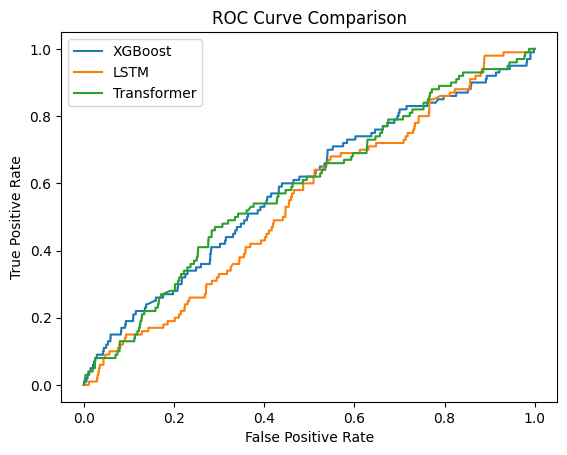

In [35]:
fpr_ml, tpr_ml, _ = roc_curve(y_test, y_pred_ml)
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_pred_dl)
fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_trans)

plt.figure()
plt.plot(fpr_ml, tpr_ml, label="XGBoost")
plt.plot(fpr_dl, tpr_dl, label="LSTM")
plt.plot(fpr_t, tpr_t, label="Transformer")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Precision - Recall Curve

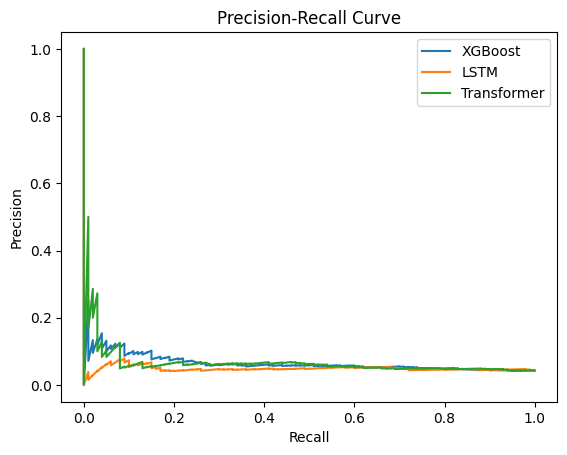

In [36]:
prec_ml, rec_ml, _ = precision_recall_curve(y_test, y_pred_ml)
prec_dl, rec_dl, _ = precision_recall_curve(y_test, y_pred_dl)
prec_t, rec_t, _ = precision_recall_curve(y_test, y_pred_trans)


plt.figure()
plt.plot(rec_ml, prec_ml, label="XGBoost")
plt.plot(rec_dl, prec_dl, label="LSTM")
plt.plot(rec_t, prec_t, label="Transformer")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.savefig("images/precision_recall_curve.png", dpi=300, bbox_inches="tight")

plt.show()

Time-based Prediction Visualization

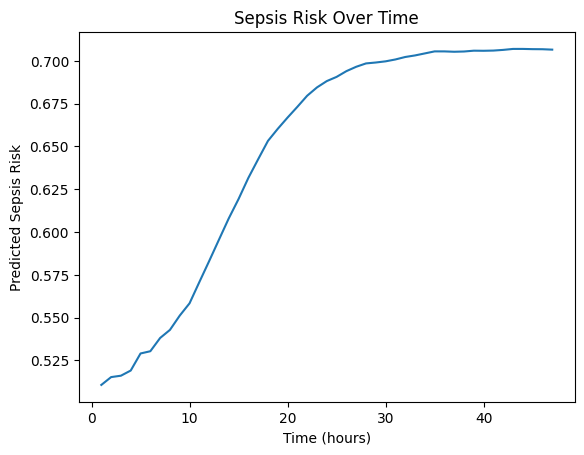

In [37]:
# Example: visualize one patient
sample = X_test[0]
preds = []

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.eval()
with torch.no_grad():
    for t in range(1, len(sample)):
        seq = torch.tensor(sample[:t+1], dtype=torch.float32).unsqueeze(0).to(device)  

        pred = torch.sigmoid(model(seq)).item()
        preds.append(pred)

plt.figure()
plt.plot(range(1, len(preds)+1), preds)
plt.xlabel("Time (hours)")
plt.ylabel("Predicted Sepsis Risk")
plt.title("Sepsis Risk Over Time")

plt.savefig("images/sepsis_risk_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

### Attention Visualization

Custom Attention Layer

In [38]:
class CustomTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64):
        super().__init__()
        
        self.input_proj = nn.Linear(input_dim, d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads=4, batch_first=True)
        self.fc = nn.Linear(d_model, 1)
        
    def forward(self, x):
        x = self.input_proj(x)
        attn_output, attn_weights = self.attn(x, x, x)
        out = attn_output[:, -1, :]
        return self.fc(out), attn_weights

Get Attention for One Patient

In [39]:
model_attn = CustomTransformer(input_dim=X_train.shape[2])

sample = torch.tensor(X_test[0]).unsqueeze(0).float()

model_attn.eval()
with torch.no_grad():
    output, attn_weights = model_attn(sample)

attn = attn_weights.squeeze().numpy()

Plot Attention Heatmap

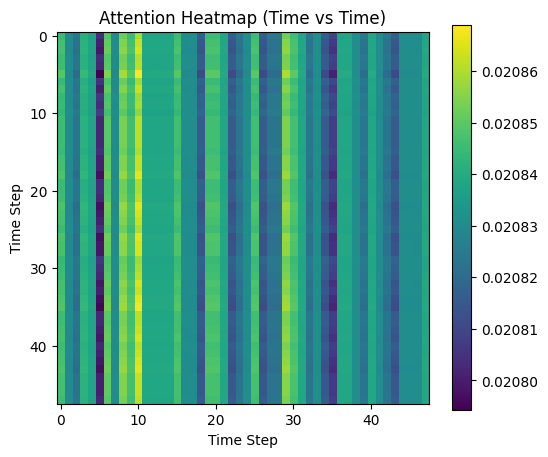

In [40]:
plt.figure(figsize=(6,5))
plt.imshow(attn, cmap="viridis")
plt.colorbar()
plt.title("Attention Heatmap (Time vs Time)")
plt.xlabel("Time Step")
plt.ylabel("Time Step")

plt.savefig("images/attention_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()